In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import LeaveOneGroupOut, cross_val_score
from sklearn.metrics import roc_curve, auc, roc_auc_score
from skimpy import skim
import optuna
import shap

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
df = pd.read_csv("world_cup_training.csv")
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types                                                                 │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓                                                          │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃                                                          │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩                                                          │
│ │ Number of rows    │ 206    │ │ int64       │ 7     │                                                          │
│ │ Number of columns │ 11     │ │ string      │ 2     │                                                          │
│ └───────────────────┴────────┘ │ float64     │ 2     │                                                          │
│                                └─────────────┴───────┘                                                          │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━━┓  │
│ ┃ column                ┃ NA  ┃ NA %  ┃ mean     ┃ sd      ┃ p0    ┃ p25    ┃ p50   ┃ p75    ┃ p100 ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━━┩  │
│ │         year          │   0 │     0 │     2010 │   8.102 │  1998 │   2002 │  2010 │   2018 │ 2022 │ ▃▃▃▃▃▇ │  │
│ │       fifa_rank       │   0 │     0 │    22.69 │    17.1 │     1 │      9 │  19.5 │  33.75 │   83 │ ▇▆▃▂▁  │  │
│ │      fifa_points      │   0 │     0 │    834.4 │   468.3 │    37 │  626.2 │   757 │   1126 │ 1841 │ ▃▃▇▃▂▂ │  │
│ │  confederation_code   │   0 │     0 │    1.209 │   1.386 │     0 │      0 │     1 │      2 │    5 │ ▇▃▃▂▁  │  │
│ │    wc_appearances     │   0 │     0 │    7.451 │   5.841 │     0 │      3 │     6 │     12 │   21 │ ▇▆▃▃▅▁ │  │
│ │     prev_wc_wins      │   0 │     0 │   0.5583 │   1.203 │     0 │      0 │     0 │      0 │    5 │  ▇▁▁   │  │
│ │        is_host        │   0 │     0 │  0.02913 │  0.1686 │     0 │      0 │     0 │      0 │    1 │   ▇    │  │
│ │     stage_reached     │   0 │     0 │    2.073 │   1.568 │     1 │      1 │     1 │   2.75 │    7 │ ▇▃▂ ▁▁ │  │
│ │          won          │   0 │     0 │  0.03398 │  0.1816 │     0 │      0 │     0 │      0 │    1 │   ▇    │  │
│ └───────────────────────┴─────┴───────┴──────────┴─────────┴───────┴────────┴───────┴────────┴──────┴────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┓  │
│ ┃            ┃    ┃      ┃          ┃            ┃         ┃            ┃ chars per ┃ words per  ┃ total     ┃  │
│ ┃ column     ┃ NA ┃ NA % ┃ shortest ┃ longest    ┃ min     ┃ max        ┃ row       ┃ row        ┃ words     ┃  │
│ ┡━━━━━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━┩  │
│ │    team    │  0 │    0 │   Togo   │ Bosnia and │ Algeria │ Yugoslavia │      7.49 │        1.1 │       234 │  │
│ │            │    │      │          │ Herzegovin │         │            │           │            │           │  │
│ │            │    │      │          │     a      │         │            │           │            │           │  │
│ │ confederat │  0 │    0 │   CAF    │  CONMEBOL  │   AFC   │    UEFA    │      4.73 │          1 │       206 │  │
│ │    ion     │    │      │          │            │         │            │           │            │           │  │
│ └────────────┴────┴──────┴──────────┴────────────┴─────────┴────────────┴───────────┴────────────┴───────────┘  │
╰────────────────────────────────────────────────────── 

In [3]:
FEATURES = [
    "fifa_rank",
    "fifa_points",
    "confederation_code",
    "wc_appearances",
    "prev_wc_wins",
    "is_host",
]

TARGET = "won"

X = df[FEATURES]
y = df[TARGET]

In [4]:
logo = LeaveOneGroupOut()
groups = df["year"]

fixed_params = {
    "n_estimators": 500,
    "class_weight": "balanced",
    "random_state": 101,
    "n_jobs": -1,
}


def objective(trial):
    tuned_params = {
        "max_depth": trial.suggest_int("max_depth", 3, 6),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 2, 3),
    }
    model = RandomForestClassifier(**fixed_params, **tuned_params)
    scores = cross_val_score(model, X, y, cv=logo, groups=groups, scoring="roc_auc")
    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=100)

print(f"Best mean AUC: {study.best_value:.3f}")
print(f"Best params: {study.best_params}")

Best mean AUC: 0.869
Best params: {'max_depth': 3, 'min_samples_leaf': 2}


In [5]:
# Build final model with best params
model = RandomForestClassifier(**fixed_params, **study.best_params)

# Manual LOGO CV to collect predictions for ROC curve
all_y_true, all_y_prob = [], []
cv_scores = []

for train_idx, test_idx in logo.split(X, y, groups):
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    y_prob = model.predict_proba(X.iloc[test_idx])[:, 1]
    year = groups.iloc[test_idx].iloc[0]
    fold_auc = roc_auc_score(y.iloc[test_idx], y_prob)
    cv_scores.append((year, fold_auc))
    all_y_true.extend(y.iloc[test_idx].values)
    all_y_prob.extend(y_prob)

print("Cross-validation:")
for year, score in cv_scores:
    bar = "|" * int(score * 20)
    print(f"Held out {year}: AUC = {score:.3f} {bar}")
print(f"Mean AUC: {np.mean([score for _, score in cv_scores]):.3f}")

# Final refit on all data
model.fit(X, y)

Cross-validation:
Held out 1998: AUC = 0.793 |||||||||||||||
Held out 2002: AUC = 0.862 |||||||||||||||||
Held out 2006: AUC = 0.926 ||||||||||||||||||
Held out 2010: AUC = 0.741 ||||||||||||||
Held out 2014: AUC = 1.000 ||||||||||||||||||||
Held out 2018: AUC = 0.900 ||||||||||||||||||
Held out 2022: AUC = 0.862 |||||||||||||||||
Mean AUC: 0.869


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

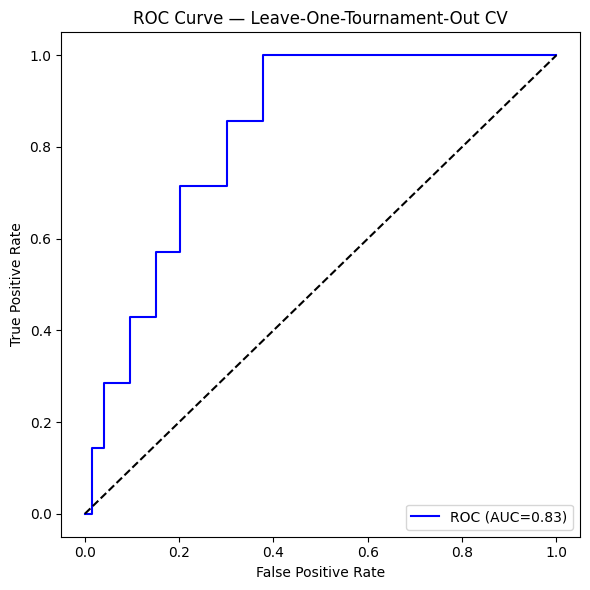

Pooled out-of-fold ROC AUC: 0.83


In [6]:
# ROC curve
fpr, tpr, _ = roc_curve(all_y_true, all_y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", label=f"ROC (AUC={roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="black", linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Leave-One-Tournament-Out CV")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"Pooled out-of-fold ROC AUC: {roc_auc:.2f}")

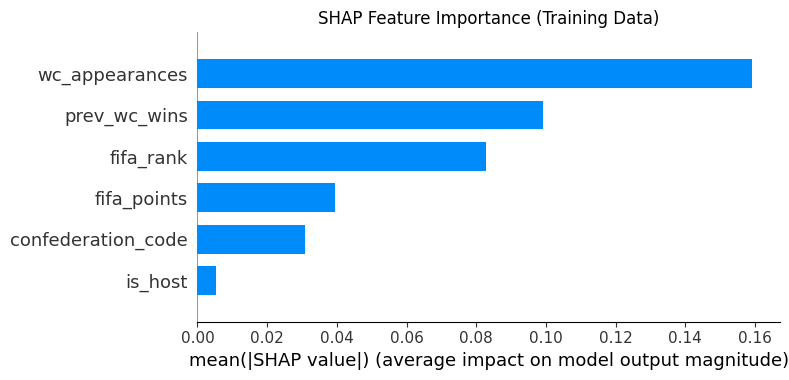

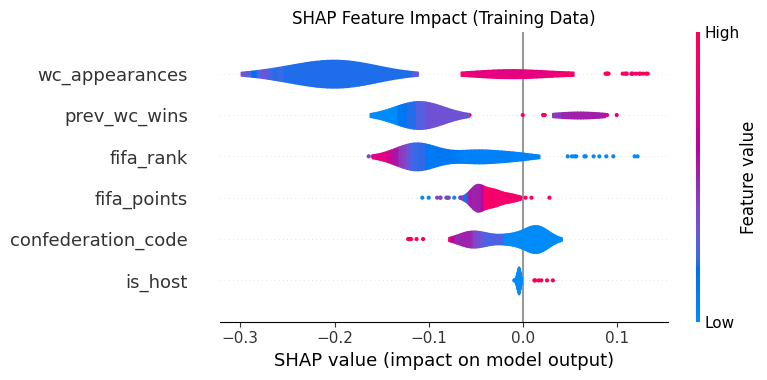

In [7]:
# SHAP on training data (positive class only)
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)[:, :, 1]

shap.summary_plot(shap_values, X, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (Training Data)")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X, plot_type="violin", show=False)
plt.title("SHAP Feature Impact (Training Data)")
plt.tight_layout()
plt.show()

In [8]:
df_2026 = pd.read_csv("world_cup_2026.csv")

X_2026 = df_2026[FEATURES]
df_2026["win_probability"] = model.predict_proba(X_2026)[:, 1]

total = df_2026["win_probability"].sum()
df_2026["win_probability_pct"] = (df_2026["win_probability"] / total * 100).round(1)

result = df_2026[["team", "confederation", "fifa_rank", "win_probability_pct"]].sort_values("win_probability_pct", ascending=False)

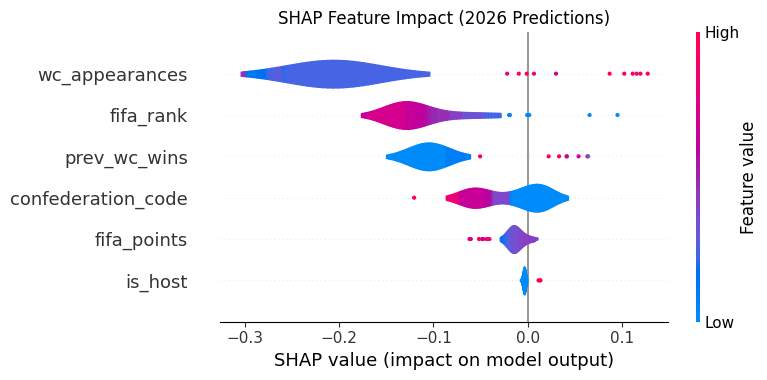


SHAP waterfall for top predicted team: Argentina


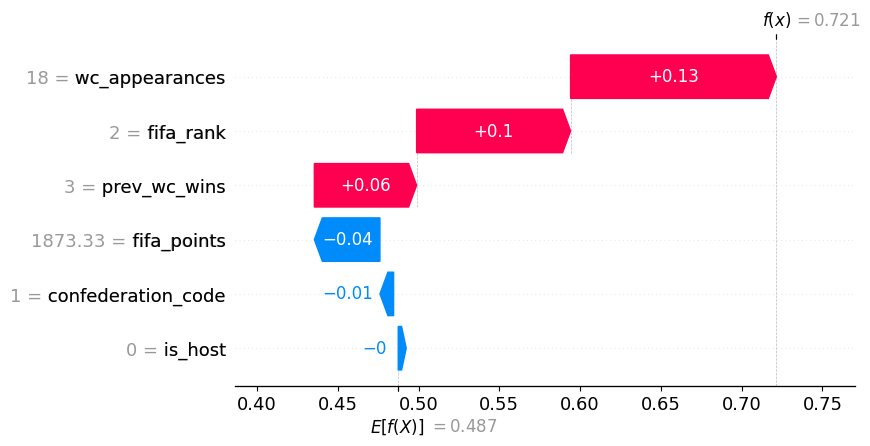

In [9]:
# SHAP on 2026 predictions (positive class only)
shap_values_2026 = explainer(X_2026)[:, :, 1]

shap.summary_plot(shap_values_2026, X_2026, plot_type="violin", show=False)
plt.title("SHAP Feature Impact (2026 Predictions)")
plt.tight_layout()
plt.show()

# Waterfall for the top predicted team
top_idx = df_2026["win_probability"].idxmax()
top_team = df_2026.loc[top_idx, "team"]
print(f"\nSHAP waterfall for top predicted team: {top_team}")
shap.plots.waterfall(shap_values_2026[top_idx])

In [10]:
print("2026 WORLD CUP - AI WIN PREDICTION")
print(f"{'Team':<20}  {'Rank':<6}  {'Probability'}")

for index in range(len(result.head(10))):
    row = result.iloc[index]
    bar = "|" * int(row["win_probability_pct"] / 2)
    print(f"{row['team']:<20}  #{int(row['fifa_rank']):<5} {bar} {row['win_probability_pct']:.1f}%")

result.to_csv("world_cup_2026_predictions.csv", index=False)

2026 WORLD CUP - AI WIN PREDICTION
Team                  Rank    Probability
Argentina             #2     |||||| 12.0%
France                #3     ||||| 11.4%
England               #4     ||||| 10.5%
Spain                 #1     |||| 9.5%
Italy                 #13    |||| 9.0%
Germany               #10    ||| 6.8%
Brazil                #5     ||| 6.0%
Uruguay               #17    || 5.6%
Belgium               #9     || 5.1%
Switzerland           #18    || 5.1%
